# ANÁLISIS DE SENSIBILIDAD — NOTEBOOK DE ANÁLISIS
---
## Imports y configuración global

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import scipy.stats as stats
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")

# ── Rutas ─────────────────────────────────────────────────────────────────────
ROOT_DIR    = Path().cwd().resolve().parents[0]
RESULTS_DIR = ROOT_DIR / "data/processed"
CSV_PATH    = RESULTS_DIR / "summary.csv"
FIGS_DIR    = Path("figures")
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# ── Estilo de figuras (compatible con LaTeX) ──────────────────────────────────
plt.rcParams.update({
    "font.family"      : "serif",
    "font.size"        : 11,
    "axes.titlesize"   : 12,
    "axes.labelsize"   : 11,
    "legend.fontsize"  : 9,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "figure.dpi"       : 150,
    "savefig.dpi"      : 300,
    "savefig.bbox"     : "tight",
})

# Paleta de colores accesible (compatible con impresión en escala de grises)
COLORS = {
    "optimal"  : "#2c7bb6",
    "below_opt": "#d7191c",
    "above_opt": "#1a9641",
    "neutral"  : "#999999",
}

print("✓ Configuración cargada.")

✓ Configuración cargada.


## Carga y saneamiento del CSV

In [2]:
df_raw = pd.read_csv(CSV_PATH)
print(f"CSV cargado: {len(df_raw)} filas, {df_raw['graph_id'].nunique()} grafos, "
      f"{df_raw['config_name'].nunique()} configuraciones.")
print(f"Grafos disponibles: {sorted(df_raw['graph_id'].unique())}")
print(f"Configs disponibles: {sorted(df_raw['config_name'].unique())}")

# ── Normaliza graph_id a string con cero a la izquierda ──────────────────────
df_raw["graph_id"] = df_raw["graph_id"].astype(str).str.zfill(3)

# ── Metadatos de categoría ────────────────────────────────────────────────────
CATEGORY_MAP = {
    "9": "small",  "051": "small",
    "3": "medium", "026": "medium", "40": "medium",
    "89": "medium", "092": "medium",
    "56": "large",  "065": "large",  "71": "large",
    "72": "large",  "094": "large",
}
df_raw["category"] = df_raw["graph_id"].map(CATEGORY_MAP).fillna("unknown")

# ── Decodifica el parámetro perturbado y su valor numérico ───────────────────
PARAM_ORDER = ["population_size", "cx_prob", "mut_prob", "tournsize"]
PARAM_LABELS = {
    "population_size": r"Tamaño de población ($\mu$)",
    "cx_prob"        : r"Prob. de cruce ($p_c$)",
    "mut_prob"        : r"Prob. de mutación ($p_m$)",
    "tournsize"      : r"Tamaño de torneo ($k$)",
}
OPTIMAL_VALUES = {
    "population_size": 50,
    "cx_prob"        : 0.7544,
    "mut_prob"        : 0.8577,
    "tournsize"       : 5,
}

def decode_config(config_name: str) -> tuple[str, float]:
    """
    Devuelve (param_name, numeric_value) para una config dada.
    Para 'optimal' devuelve ('optimal', nan).
    """
    if config_name == "optimal":
        return ("optimal", float("nan"))
    for param in PARAM_ORDER:
        if config_name.startswith(param + "_"):
            raw = config_name[len(param) + 1:].replace("p", ".")
            try:
                return (param, float(raw))
            except ValueError:
                return (param, float("nan"))
    return ("unknown", float("nan"))

df_raw[["param", "param_value"]] = df_raw["config_name"].apply(
    lambda x: pd.Series(decode_config(x))
)

# ── Verifica completitud (cada celda debe tener N_RUNS filas) ─────────────────
counts = df_raw.groupby(["graph_id", "config_name"]).size().unstack(fill_value=0)
expected_runs = df_raw["run_id"].nunique() + 1  # 0..N-1
missing = (counts < 30).sum().sum()
print(f"\n{'⚠ ADVERTENCIA' if missing else '✓'}: "
      f"{'Hay ' + str(missing) + ' combinaciones con <30 runs.' if missing else 'Todas las combinaciones tienen 30 runs.'}")
# print(counts.to_string())

CSV cargado: 4080 filas, 8 grafos, 17 configuraciones.
Grafos disponibles: [3, 9, 26, 40, 51, 56, 89, 92]
Configs disponibles: ['cx_prob_0p6', 'cx_prob_0p68', 'cx_prob_0p83', 'cx_prob_0p95', 'mut_prob_0p5', 'mut_prob_0p7', 'mut_prob_0p93', 'mut_prob_0p99', 'optimal', 'population_size_100', 'population_size_25', 'population_size_38', 'population_size_65', 'tournsize_2', 'tournsize_3', 'tournsize_7', 'tournsize_9']

✓: Todas las combinaciones tienen 30 runs.


## Tabla de resumen agregado (MBF, SR, AES)

In [3]:
df_raw["gap_pct"] = 100.0 * (df_raw["final_best"] - df_raw["baseline"]) / df_raw["baseline"].clip(lower=1)
df_raw["aes_numeric"] = pd.to_numeric(df_raw["aes"], errors="coerce")

agg_dict = {
    "final_best"  : ["mean", "std"],
    "success"     : "mean",
    "aes_numeric" : ["mean", "std"],
    "gap_pct"     : "mean",
    "n_vertices"  : "first",
    "baseline"    : "first",
    "category"    : "first",
}
summary = (
    df_raw
    .groupby(["graph_id", "config_name", "param", "param_value"])
    .agg(agg_dict)
)
summary.columns = ["mbf", "mbf_std", "sr", "aes_mean", "aes_std",
                   "gap_pct_mean", "n_vertices", "baseline", "category"]
summary = summary.reset_index()

# Referencia óptima por grafo
opt_ref = (
    summary[summary["config_name"] == "optimal"]
    [["graph_id", "mbf", "mbf_std"]]
    .rename(columns={"mbf": "opt_mbf", "mbf_std": "opt_mbf_std"})
)
summary = summary.merge(opt_ref, on="graph_id", how="left")
summary["delta_mbf"]   = summary["mbf"] - summary["opt_mbf"]
summary["sig_degraded"] = summary["delta_mbf"] > summary["opt_mbf_std"]

print(summary[["graph_id", "config_name", "mbf", "mbf_std", "sr", "aes_mean",
               "gap_pct_mean", "sig_degraded"]].to_string(index=False))

graph_id         config_name         mbf    mbf_std       sr    aes_mean  gap_pct_mean  sig_degraded
     003         cx_prob_0p6  517.533333  34.002772 0.000000         NaN     59.241026         False
     003        cx_prob_0p68  506.166667  30.415608 0.000000         NaN     55.743590         False
     003        cx_prob_0p83  507.833333  36.734916 0.000000         NaN     56.256410         False
     003        cx_prob_0p95  499.633333  30.842742 0.000000         NaN     53.733333         False
     003        mut_prob_0p5  516.533333  35.710264 0.000000         NaN     58.933333         False
     003        mut_prob_0p7  508.766667  33.538124 0.000000         NaN     56.543590         False
     003       mut_prob_0p93  498.433333  41.513341 0.000000         NaN     53.364103         False
     003       mut_prob_0p99  508.500000  27.614027 0.000000         NaN     56.461538         False
     003 population_size_100  618.866667  35.812475 0.000000         NaN     90.420513     

## FIGURA 1: Análisis de sensibilidad (MBF y SR por parámetro)

Una figura con 4 columnas (un parámetro cada una) y 2 filas:
- Fila superior: MBF promedio ± 1 std (barras de error)
- Fila inferior: SR (%) como barras

La línea vertical marca el valor óptimo Θ*.

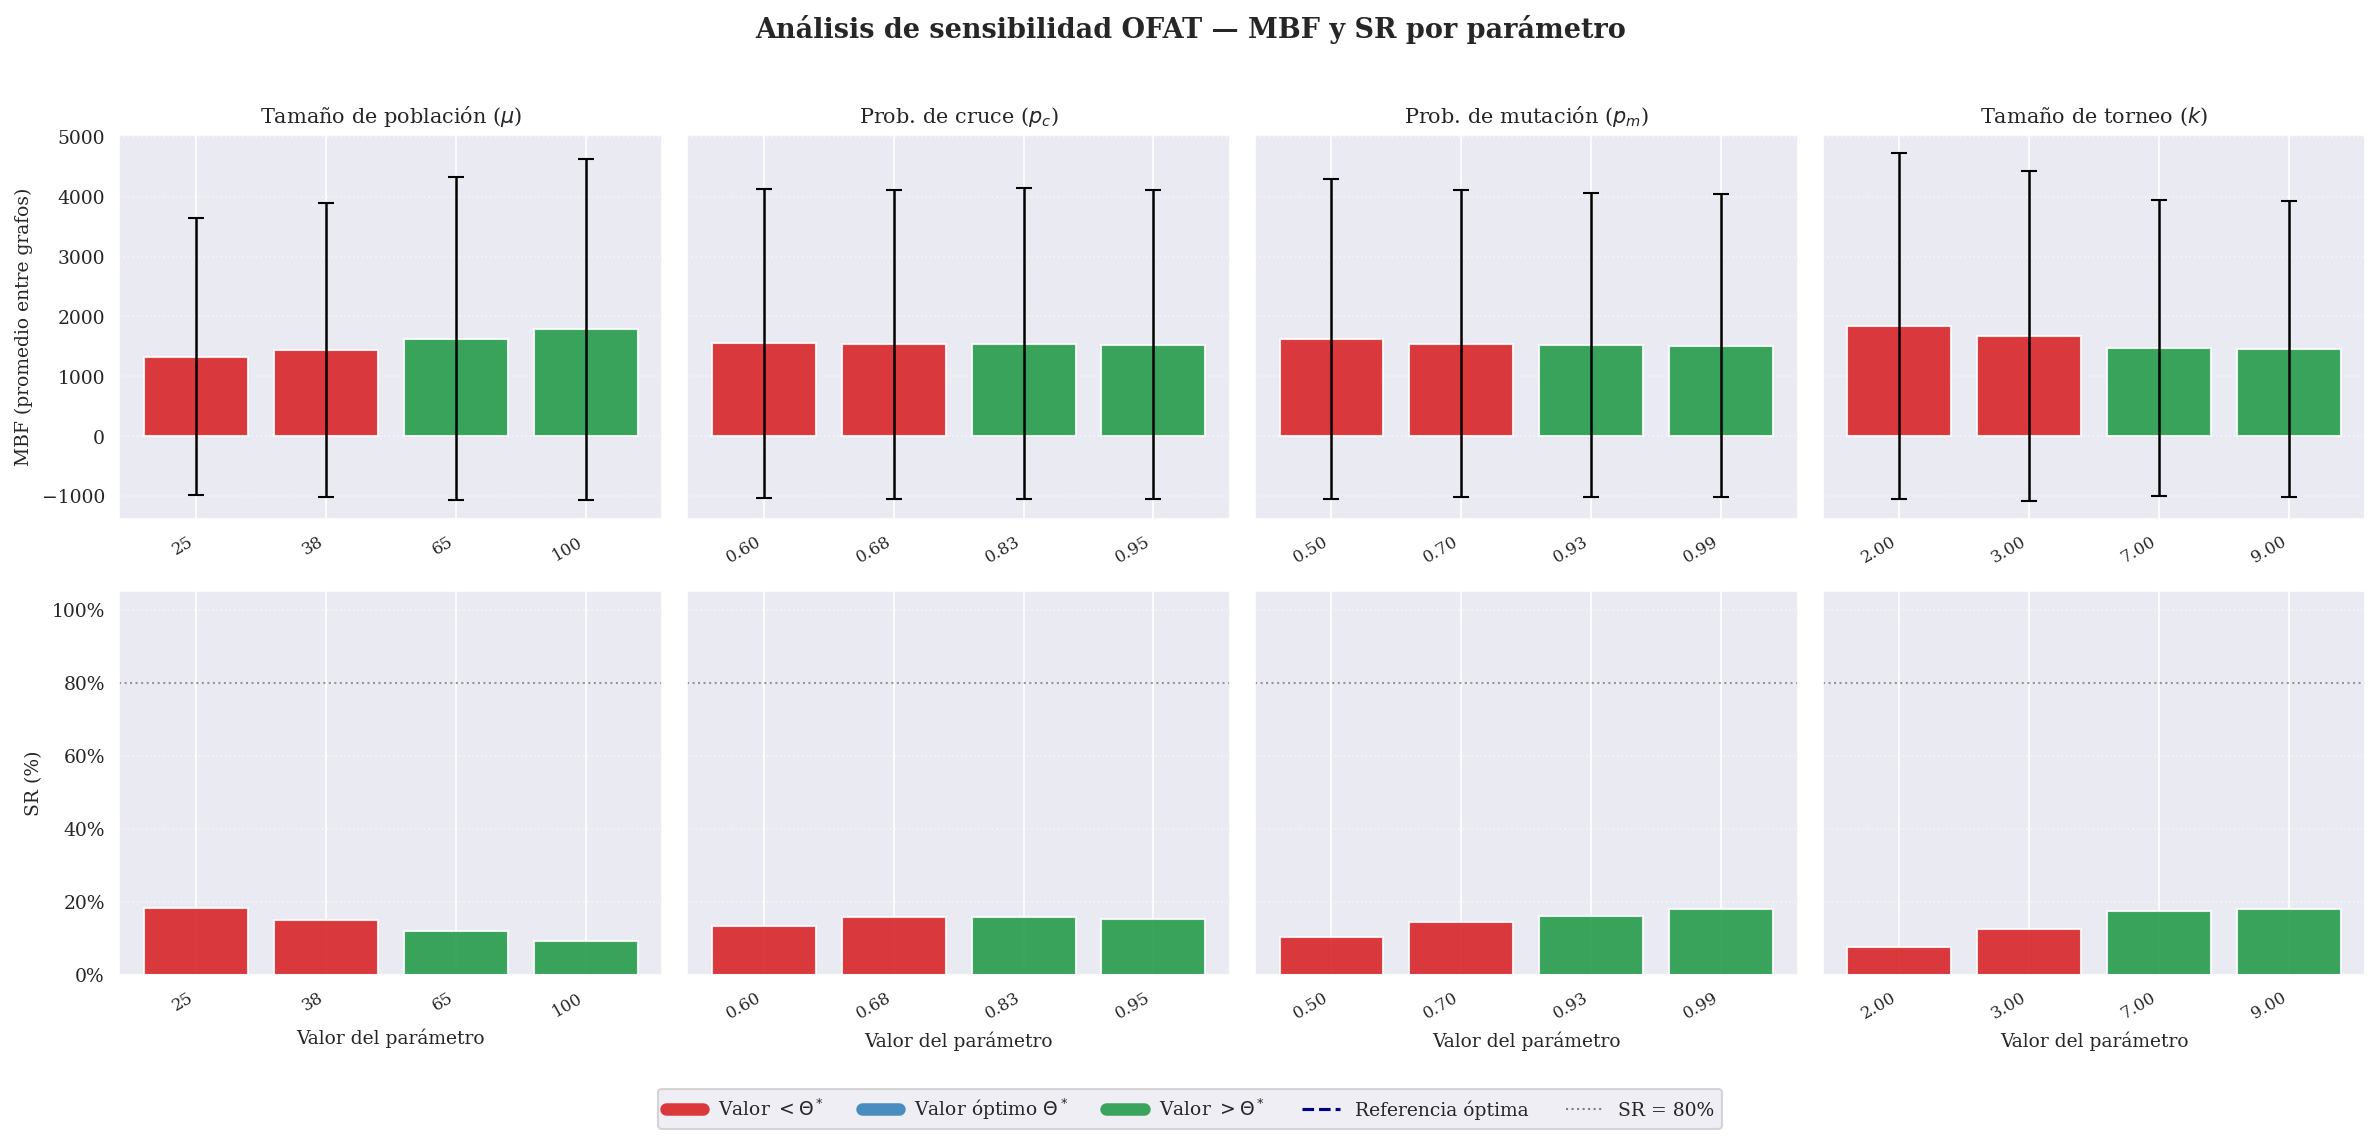

✓ Figura guardada en figures/fig1_sensitivity_mbf_sr.pdf


In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey="row")
fig.suptitle("Análisis de sensibilidad OFAT — MBF y SR por parámetro",
             fontsize=13, fontweight="bold", y=1.01)

for col_idx, param in enumerate(PARAM_ORDER):
    opt_val    = OPTIMAL_VALUES[param]
    param_data = summary[summary["param"] == param].copy()

    # Agrega el punto óptimo (promedio sobre todos los grafos disponibles)
    opt_point = summary[summary["config_name"] == "optimal"].copy()
    opt_point["param"]       = param
    opt_point["param_value"] = opt_val
    param_data = pd.concat([param_data, opt_point], ignore_index=True)

    # Agrega sobre grafos (promedio ponderado simple)
    grouped = (
        param_data
        .groupby("param_value")
        .agg(
            mbf_mean=("mbf", "mean"),
            mbf_std =("mbf", "mean"),   # std del promedio entre grafos
            sr_mean =("sr",  "mean"),
        )
        .reset_index()
        .sort_values("param_value")
    )

    # También calcula std real entre grafos para las barras de error
    grouped["mbf_std"] = (
        param_data.groupby("param_value")["mbf"].std().reindex(grouped["param_value"]).values
    )

    xs     = grouped["param_value"].values
    mbf    = grouped["mbf_mean"].values
    mbf_s  = grouped["mbf_std"].fillna(0).values
    sr     = grouped["sr_mean"].values * 100

    bar_colors = [
        COLORS["optimal"] if np.isclose(x, opt_val, rtol=1e-3) else
        (COLORS["below_opt"] if x < opt_val else COLORS["above_opt"])
        for x in xs
    ]

    # ── Fila 0: MBF ──────────────────────────────────────────────────────────
    ax_mbf = axes[0][col_idx]
    ax_mbf.bar(range(len(xs)), mbf, color=bar_colors, alpha=0.85, zorder=2)
    ax_mbf.errorbar(range(len(xs)), mbf, yerr=mbf_s, fmt="none",
                    color="black", capsize=4, linewidth=1.2, zorder=3)

    opt_idx = [i for i, x in enumerate(xs) if np.isclose(x, opt_val, rtol=1e-3)]
    if opt_idx:
        ax_mbf.axvline(opt_idx[0], color="navy", linewidth=1.5,
                       linestyle="--", alpha=0.7, zorder=1)

    ax_mbf.set_xticks(range(len(xs)))
    ax_mbf.set_xticklabels(
        [f"{x:.2f}" if isinstance(x, float) and x < 10 else f"{int(x)}" for x in xs],
        rotation=30, ha="right", fontsize=8
    )
    ax_mbf.set_title(PARAM_LABELS[param], fontsize=10)
    if col_idx == 0:
        ax_mbf.set_ylabel("MBF (promedio entre grafos)", fontsize=9)
    ax_mbf.grid(axis="y", linestyle=":", alpha=0.5)
    ax_mbf.set_axisbelow(True)

    # ── Fila 1: SR ───────────────────────────────────────────────────────────
    ax_sr = axes[1][col_idx]
    ax_sr.bar(range(len(xs)), sr, color=bar_colors, alpha=0.85, zorder=2)

    if opt_idx:
        ax_sr.axvline(opt_idx[0], color="navy", linewidth=1.5,
                      linestyle="--", alpha=0.7, zorder=1)
    ax_sr.axhline(80, color="gray", linewidth=1, linestyle=":", alpha=0.8)
    ax_sr.set_ylim(0, 105)
    ax_sr.set_xticks(range(len(xs)))
    ax_sr.set_xticklabels(
        [f"{x:.2f}" if isinstance(x, float) and x < 10 else f"{int(x)}" for x in xs],
        rotation=30, ha="right", fontsize=8
    )
    if col_idx == 0:
        ax_sr.set_ylabel("SR (%)", fontsize=9)
    ax_sr.set_xlabel("Valor del parámetro", fontsize=9)
    ax_sr.grid(axis="y", linestyle=":", alpha=0.5)
    ax_sr.set_axisbelow(True)
    ax_sr.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

# Leyenda global
legend_elements = [
    Line2D([0], [0], color=COLORS["below_opt"], lw=6, alpha=0.85, label=r"Valor $<\Theta^*$"),
    Line2D([0], [0], color=COLORS["optimal"],   lw=6, alpha=0.85, label=r"Valor óptimo $\Theta^*$"),
    Line2D([0], [0], color=COLORS["above_opt"], lw=6, alpha=0.85, label=r"Valor $>\Theta^*$"),
    Line2D([0], [0], color="navy", lw=1.5, linestyle="--", label="Referencia óptima"),
    Line2D([0], [0], color="gray", lw=1,   linestyle=":", label="SR = 80%"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=5,
           bbox_to_anchor=(0.5, -0.06), frameon=True)

plt.tight_layout()
fig.savefig(FIGS_DIR / "fig1_sensitivity_mbf_sr.pdf")
fig.savefig(FIGS_DIR / "fig1_sensitivity_mbf_sr.png")
plt.show()
print(f"✓ Figura guardada en {FIGS_DIR}/fig1_sensitivity_mbf_sr.pdf")

## FIGURA 2: Curvas de convergencia por parámetro perturbado

Para cada uno de los 4 parámetros, una subfigura con la mediana del mejor fitness vs. evaluaciones (promediando sobre grafos de la misma categoría). Cada línea = un nivel de perturbación; la óptima en azul punteado grueso.

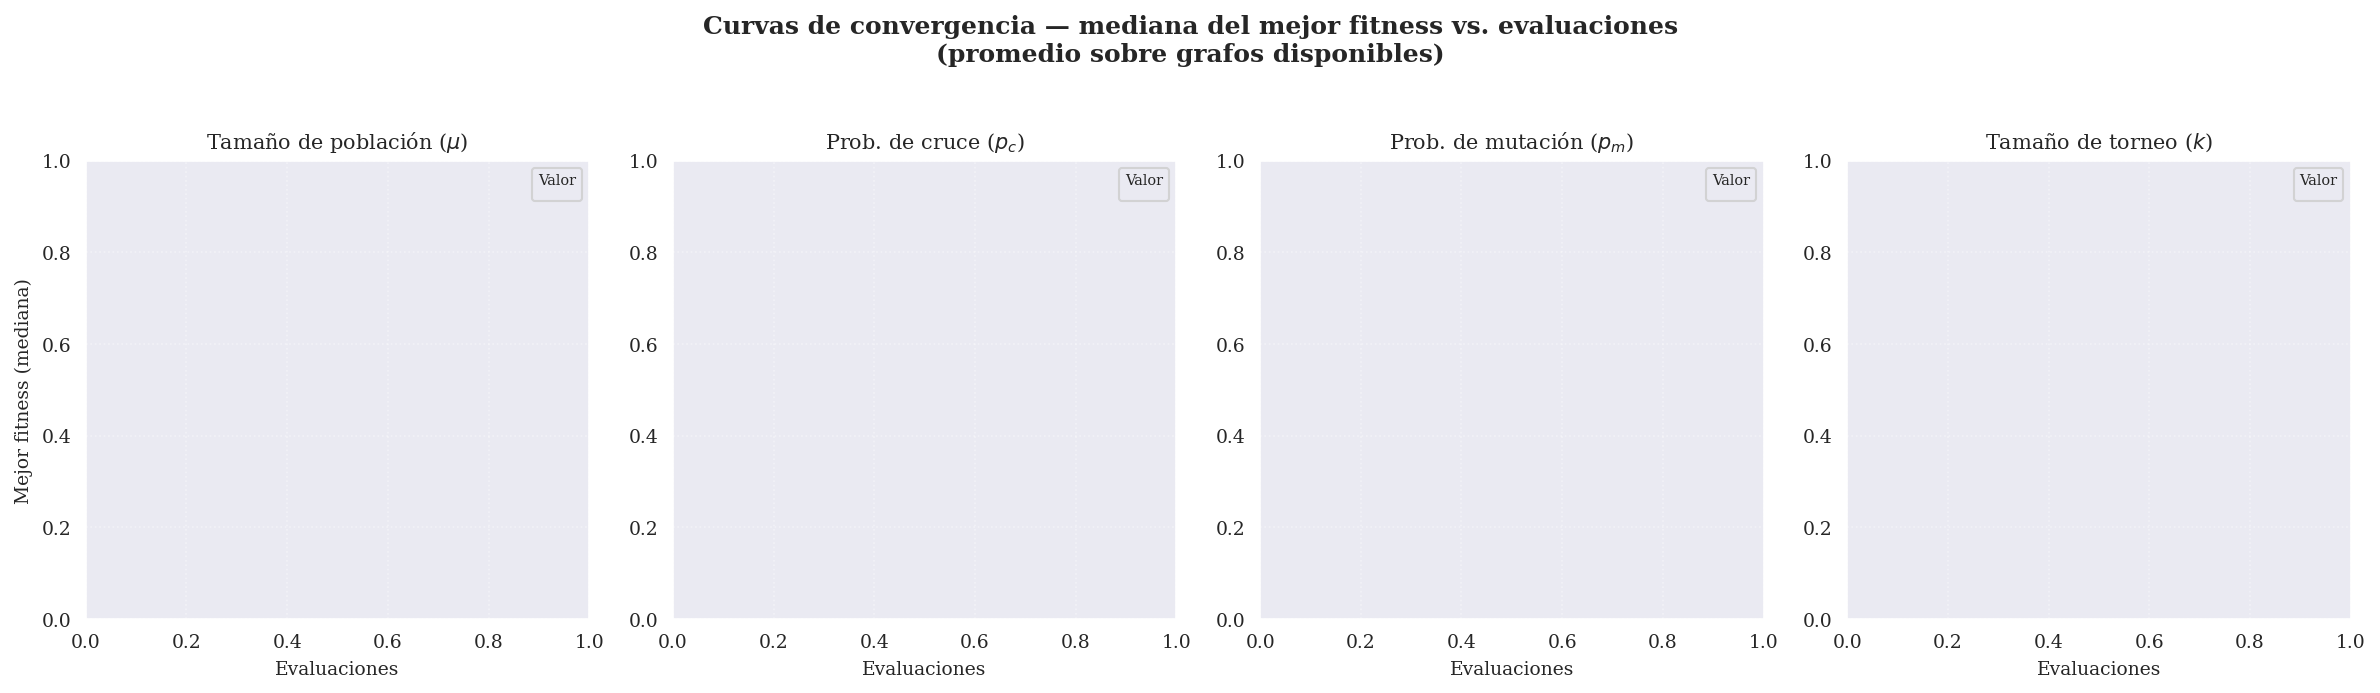

✓ Figura guardada en figures/fig2_convergence_curves.pdf


In [5]:
def load_convergence_for_config(results_dir: Path, graph_id: str, config_name: str
                                ) -> tuple[np.ndarray, np.ndarray] | None:
    """
    Carga el JSON de un (graph_id, config_name) y devuelve
    (evals_common, best_median) donde best_median es la mediana de las 30 runs
    interpolada a una grilla común de evaluaciones.
    """
    path = results_dir / f"graph_{graph_id}_{config_name}.json"
    if not path.exists():
        return None

    with open(path) as f:
        data = json.load(f)

    all_evals = []
    all_bests = []
    for run in data["runs"]:
        e = np.array(run["evals"])
        b = np.array(run["best_per_gen"])
        all_evals.append(e)
        all_bests.append(b)

    # Grilla común: unión de todos los puntos de evaluación presentes
    max_eval = max(e[-1] for e in all_evals)
    grid = np.linspace(0, max_eval, 200)

    interpolated = []
    for e, b in zip(all_evals, all_bests):
        # Interpolación escalonada (el mejor fitness no puede empeorar)
        b_interp = np.interp(grid, e, b)
        interpolated.append(b_interp)

    median_curve = np.median(interpolated, axis=0)
    return grid, median_curve


def load_convergence_matrix(results_dir, graph_ids, config_name):
    """Promedia curvas de convergencia sobre múltiples grafos para una config."""
    curves = []
    for gid in graph_ids:
        result = load_convergence_for_config(results_dir, gid, config_name)
        if result is None:
            continue
        grid, curve = result
        # Normaliza a grilla de 200 puntos en [0, MAX_EVAL]
        grid_norm = np.linspace(grid[0], grid[-1], 200)
        curve_norm = np.interp(grid_norm, grid, curve)
        curves.append(curve_norm)

    if not curves:
        return None, None

    # Normaliza a un grid común [0,1] para comparar entre grafos con distintos E_max
    common_grid = np.linspace(0, 2000, 200)
    return common_grid, np.mean(curves, axis=0)


# Identifica todos los config_names disponibles
available_graphs = sorted(df_raw["graph_id"].unique())
all_configs_list = sorted(df_raw["config_name"].unique())

# Paleta de líneas para niveles (gradiente de intensidad)
LEVEL_PALETTE = ["#d73027", "#fc8d59", "#2c7bb6", "#91bfdb", "#1a9641", "#74c476"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), sharey=False)
fig.suptitle("Curvas de convergencia — mediana del mejor fitness vs. evaluaciones\n"
             "(promedio sobre grafos disponibles)",
             fontsize=12, fontweight="bold", y=1.02)

for col_idx, param in enumerate(PARAM_ORDER):
    ax = axes[col_idx]

    # Configs relevantes: las de este parámetro + la óptima
    param_configs = [c for c in all_configs_list if c.startswith(param + "_")]
    param_configs_sorted = sorted(param_configs, key=lambda c: decode_config(c)[1])
    all_relevant = param_configs_sorted  # óptima se añade aparte

    line_colors = LEVEL_PALETTE[:len(all_relevant)]

    for cfg, color in zip(all_relevant, line_colors):
        grid, curve = load_convergence_matrix(RESULTS_DIR, available_graphs, cfg)
        if curve is None:
            continue
        val = decode_config(cfg)[1]
        label = f"{val:.2f}" if val < 10 else str(int(val))
        ax.plot(grid, curve, color=color, linewidth=1.3, alpha=0.85, label=label)

    # Óptima
    grid_opt, curve_opt = load_convergence_matrix(RESULTS_DIR, available_graphs, "optimal")
    if curve_opt is not None:
        ax.plot(grid_opt, curve_opt, color=COLORS["optimal"],
                linewidth=2.2, linestyle="--", label=r"$\Theta^*$", zorder=5)

    ax.set_title(PARAM_LABELS[param], fontsize=10)
    ax.set_xlabel("Evaluaciones", fontsize=9)
    if col_idx == 0:
        ax.set_ylabel("Mejor fitness (mediana)", fontsize=9)
    ax.grid(linestyle=":", alpha=0.4)
    ax.set_axisbelow(True)

    # Leyenda dentro del gráfico
    leg = ax.legend(title="Valor", fontsize=7, title_fontsize=7,
                    loc="upper right", framealpha=0.8)

plt.tight_layout()
fig.savefig(FIGS_DIR / "fig2_convergence_curves.pdf")
fig.savefig(FIGS_DIR / "fig2_convergence_curves.png")
plt.show()
print(f"✓ Figura guardada en {FIGS_DIR}/fig2_convergence_curves.pdf")

## Boxplots de distribución de final_best por config

Para cada parámetro, boxplots de los 30 × n_grafos valores de final_best normalizados como gap% respecto al baseline (mínimo grado). Permite ver la varianza, no solo el promedio.

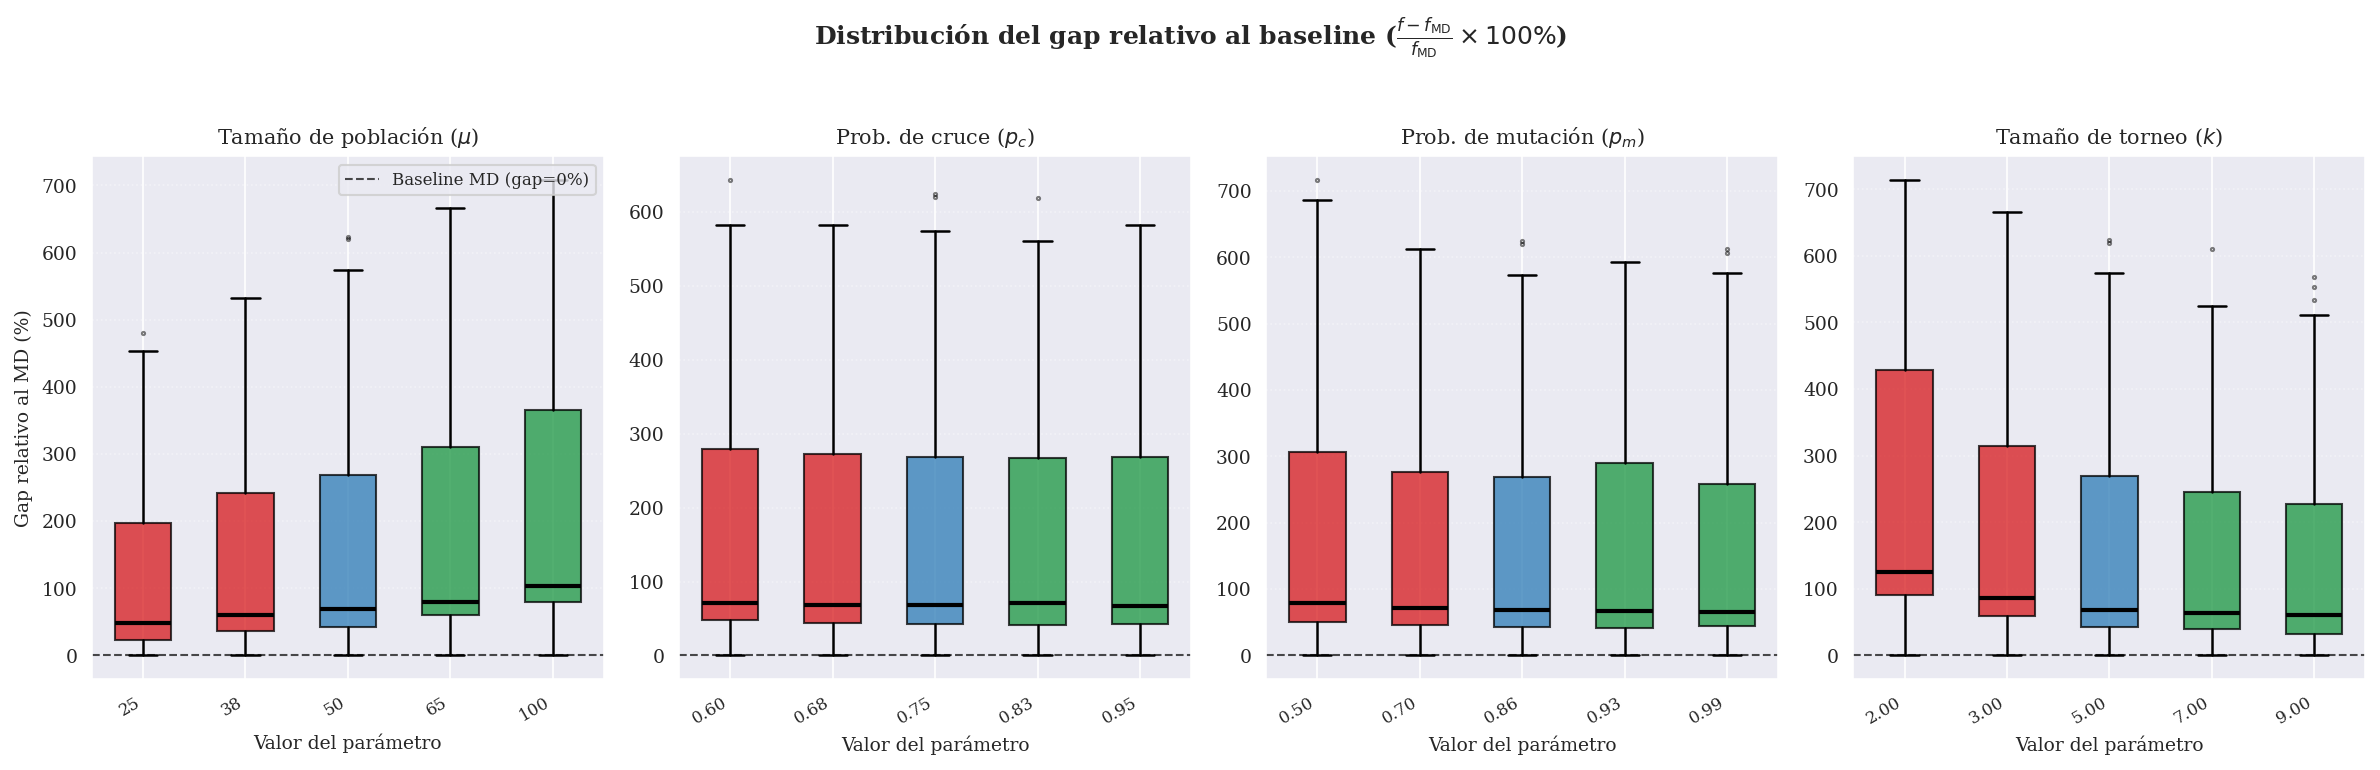

✓ Figura guardada en figures/fig3_gap_boxplots.pdf


In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)
fig.suptitle(r"Distribución del gap relativo al baseline ($\frac{f - f_{\mathrm{MD}}}{f_{\mathrm{MD}}} \times 100\%$)",
             fontsize=12, fontweight="bold", y=1.02)

for col_idx, param in enumerate(PARAM_ORDER):
    ax = axes[col_idx]

    param_data = df_raw[df_raw["param"] == param].copy()
    opt_data   = df_raw[df_raw["config_name"] == "optimal"].copy()
    opt_data["param_value"] = OPTIMAL_VALUES[param]

    combined = pd.concat([param_data, opt_data], ignore_index=True)
    combined  = combined.sort_values("param_value")

    levels      = sorted(combined["param_value"].unique())
    groups      = [combined[combined["param_value"] == lv]["gap_pct"].values
                   for lv in levels]
    tick_labels = [f"{x:.2f}" if x < 10 else str(int(x)) for x in levels]
    box_colors  = [
        COLORS["optimal"] if np.isclose(x, OPTIMAL_VALUES[param], rtol=1e-3) else
        (COLORS["below_opt"] if x < OPTIMAL_VALUES[param] else COLORS["above_opt"])
        for x in levels
    ]

    bp = ax.boxplot(
        groups,
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker=".", markersize=3, alpha=0.5),
        widths=0.55,
    )
    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.7,
               label="Baseline MD (gap=0%)")
    ax.set_xticks(range(1, len(levels) + 1))
    ax.set_xticklabels(tick_labels, rotation=30, ha="right", fontsize=8)
    ax.set_title(PARAM_LABELS[param], fontsize=10)
    ax.set_xlabel("Valor del parámetro", fontsize=9)
    if col_idx == 0:
        ax.set_ylabel("Gap relativo al MD (%)", fontsize=9)
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.set_axisbelow(True)

axes[0].legend(fontsize=8, loc="upper right")

plt.tight_layout()
fig.savefig(FIGS_DIR / "fig3_gap_boxplots.pdf")
fig.savefig(FIGS_DIR / "fig3_gap_boxplots.png")
plt.show()
print(f"✓ Figura guardada en {FIGS_DIR}/fig3_gap_boxplots.pdf")

## FIGURA 4: Heatmap de SR por (grafo × config)

Muestra de un vistazo en qué instancias y configuraciones el algoritmo falla. Solo la óptima + las configuraciones perturbadas de cada parámetro.

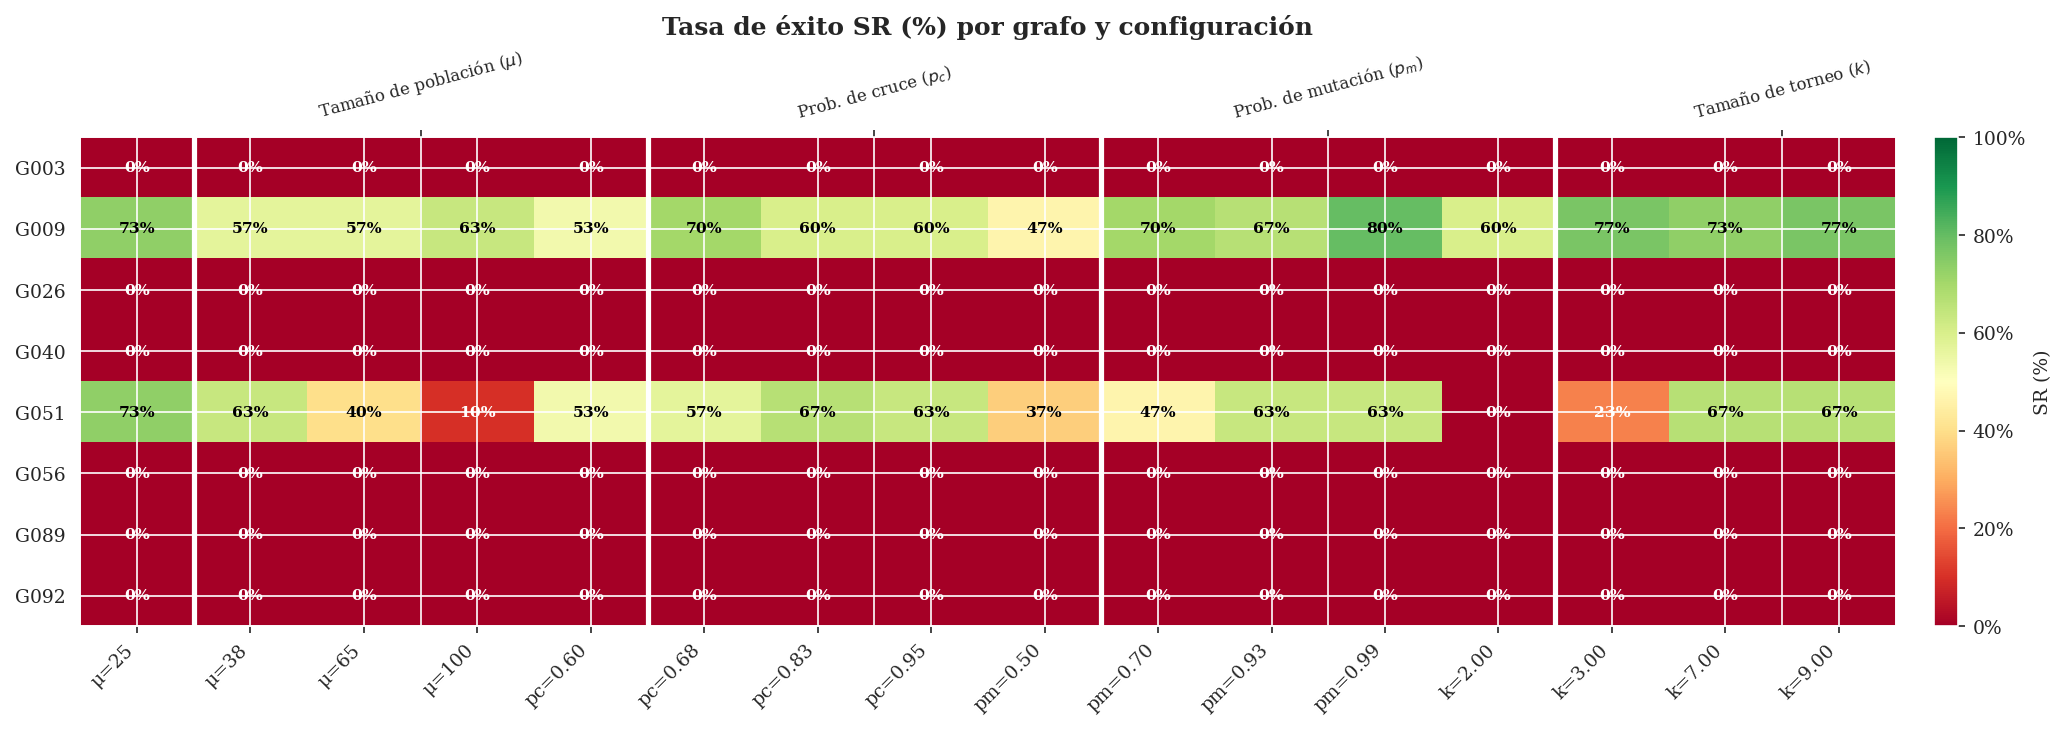

✓ Figura guardada en figures/fig4_sr_heatmap.pdf


In [7]:
pivot_sr = (
    summary
    .pivot_table(index="graph_id", columns="config_name", values="sr", aggfunc="mean")
    * 100
)

# Ordena columnas: óptima primero, luego por parámetro
col_order = ["optimal"]
for param in PARAM_ORDER:
    cols = sorted(
        [c for c in pivot_sr.columns if c.startswith(param + "_")],
        key=lambda c: decode_config(c)[1]
    )
    col_order += cols

pivot_sr = pivot_sr[[c for c in col_order if c in pivot_sr.columns]]

# Etiquetas legibles para columnas
def short_label(name):
    if name == "optimal":
        return r"$\Theta^*$"
    param, val = decode_config(name)
    abbrev = {"population_size": "μ", "cx_prob": "pc",
              "mut_prob": "pm", "tournsize": "k"}
    p = abbrev.get(param, param)
    v = f"{val:.2f}" if val < 10 else str(int(val))
    return f"{p}={v}"

col_labels = [short_label(c) for c in pivot_sr.columns]

# Separadores visuales entre parámetros (líneas verticales)
separators = [1]  # después de optimal
count = 1
for param in PARAM_ORDER:
    n = sum(1 for c in pivot_sr.columns if c.startswith(param + "_"))
    separators.append(separators[-1] + n)
    count += n

fig, ax = plt.subplots(figsize=(max(14, len(pivot_sr.columns) * 0.7), 5))

im = ax.imshow(
    pivot_sr.values,
    cmap="RdYlGn",
    vmin=0, vmax=100,
    aspect="auto",
)

# Añade valores en cada celda
for i in range(pivot_sr.shape[0]):
    for j in range(pivot_sr.shape[1]):
        val = pivot_sr.values[i, j]
        if not np.isnan(val):
            color = "white" if (val < 25 or val > 90) else "black"
            ax.text(j, i, f"{val:.0f}%", ha="center", va="center",
                    fontsize=7.5, color=color, fontweight="bold")

# Separadores visuales
for sep in separators[:-1]:
    ax.axvline(sep - 0.5, color="white", linewidth=2.5)

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(pivot_sr.index)))
ax.set_yticklabels([f"G{gid}" for gid in pivot_sr.index], fontsize=9)
ax.set_title("Tasa de éxito SR (%) por grafo y configuración", fontsize=12,
             fontweight="bold")

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("SR (%)", fontsize=9)
cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

# Etiquetas de grupo de parámetros en el eje x superior
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
group_centers = []
group_names   = []
start = 1
for param in PARAM_ORDER:
    n = sum(1 for c in pivot_sr.columns if c.startswith(param + "_"))
    if n > 0:
        group_centers.append(start + (n - 1) / 2)
        group_names.append(PARAM_LABELS[param])
        start += n
ax2.set_xticks(group_centers)
ax2.set_xticklabels(group_names, fontsize=8, rotation=15, ha="center")
ax2.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

plt.tight_layout()
fig.savefig(FIGS_DIR / "fig4_sr_heatmap.pdf")
fig.savefig(FIGS_DIR / "fig4_sr_heatmap.png")
plt.show()
print(f"✓ Figura guardada en {FIGS_DIR}/fig4_sr_heatmap.pdf")

## FIGURA 5: AES por parámetro (solo ejecuciones exitosas)

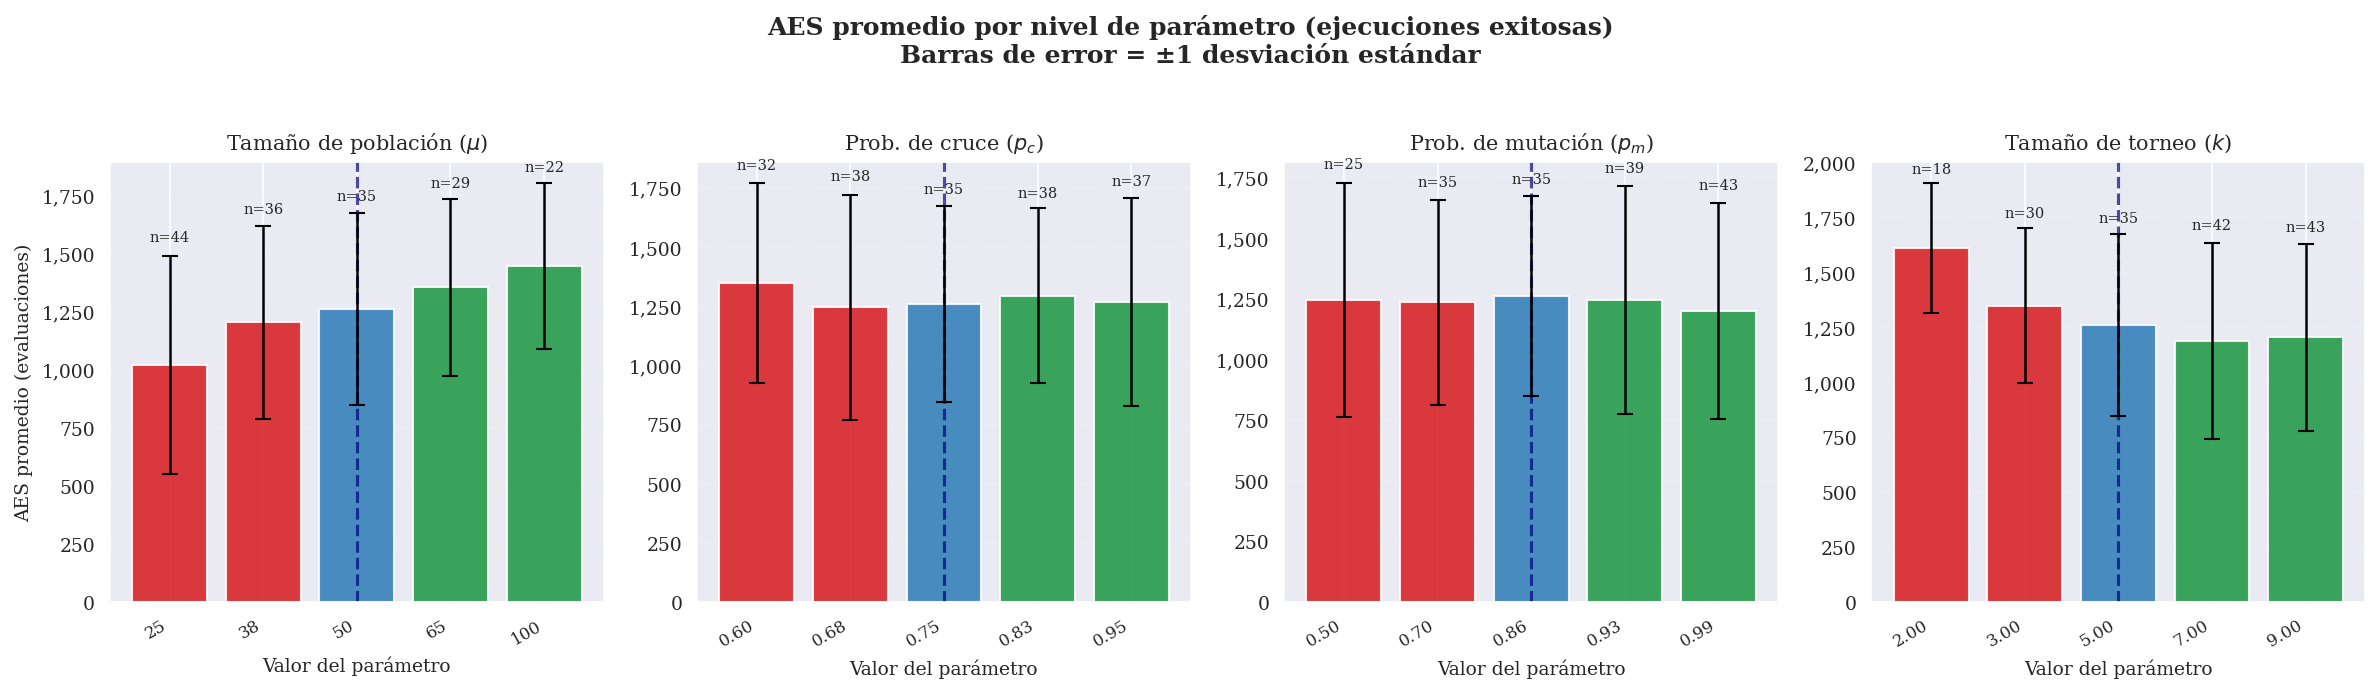

✓ Figura guardada en figures/fig5_aes_by_param.pdf


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), sharey=False)
fig.suptitle("AES promedio por nivel de parámetro (ejecuciones exitosas)\n"
             "Barras de error = ±1 desviación estándar",
             fontsize=12, fontweight="bold", y=1.02)

for col_idx, param in enumerate(PARAM_ORDER):
    ax = axes[col_idx]

    param_aes = df_raw[df_raw["param"] == param].copy()
    opt_aes   = df_raw[df_raw["config_name"] == "optimal"].copy()
    opt_aes["param_value"] = OPTIMAL_VALUES[param]
    combined = pd.concat([param_aes, opt_aes], ignore_index=True)

    # Solo ejecuciones exitosas
    combined = combined[combined["success"] == 1]

    if combined.empty:
        ax.set_title(f"{PARAM_LABELS[param]}\n(sin datos)", fontsize=9)
        continue

    grouped = (
        combined.groupby("param_value")["aes_numeric"]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values("param_value")
    )
    grouped["std"] = grouped["std"].fillna(0)

    xs = grouped["param_value"].values
    bar_colors = [
        COLORS["optimal"] if np.isclose(x, OPTIMAL_VALUES[param], rtol=1e-3) else
        (COLORS["below_opt"] if x < OPTIMAL_VALUES[param] else COLORS["above_opt"])
        for x in xs
    ]

    ax.bar(range(len(xs)), grouped["mean"], color=bar_colors, alpha=0.85, zorder=2)
    ax.errorbar(range(len(xs)), grouped["mean"], yerr=grouped["std"],
                fmt="none", color="black", capsize=4, linewidth=1.2, zorder=3)

    # Anotación con n de runs exitosos
    for i, (n_ok, mean) in enumerate(zip(grouped["count"], grouped["mean"])):
        ax.text(i, mean + grouped["std"].iloc[i] * 1.1,
                f"n={int(n_ok)}", ha="center", va="bottom", fontsize=7)

    opt_idx = [i for i, x in enumerate(xs) if np.isclose(x, OPTIMAL_VALUES[param], rtol=1e-3)]
    if opt_idx:
        ax.axvline(opt_idx[0], color="navy", linewidth=1.5, linestyle="--", alpha=0.7)

    ax.set_xticks(range(len(xs)))
    ax.set_xticklabels(
        [f"{x:.2f}" if x < 10 else str(int(x)) for x in xs],
        rotation=30, ha="right", fontsize=8
    )
    ax.set_title(PARAM_LABELS[param], fontsize=10)
    ax.set_xlabel("Valor del parámetro", fontsize=9)
    if col_idx == 0:
        ax.set_ylabel("AES promedio (evaluaciones)", fontsize=9)
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.set_axisbelow(True)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
fig.savefig(FIGS_DIR / "fig5_aes_by_param.pdf")
fig.savefig(FIGS_DIR / "fig5_aes_by_param.png")
plt.show()
print(f"✓ Figura guardada en {FIGS_DIR}/fig5_aes_by_param.pdf")

## Tabla LaTeX: resumen de métricas por grafo y configuración óptima

In [9]:
GRAPH_METADATA = {
    "009": (27, "small"),  "051": (40, "small"),
    "003": (101, "medium"), "026": (120, "medium"), "040": (147, "medium"),
    "089": (138, "medium"), "092": (132, "medium"),
    "056": (276, "large"),  "065": (276, "large"),  "071": (301, "large"),
    "072": (301, "large"),  "094": (357, "large"),
}

opt_summary = summary[summary["config_name"] == "optimal"].copy()
opt_summary = opt_summary.sort_values(["category", "n_vertices"])

lines = []
lines.append(r"\begin{table}[ht]")
lines.append(r"\centering")
lines.append(r"\caption{Métricas de desempeño del AE con configuración óptima $\Theta^*$ "
             r"sobre el conjunto de prueba parcial ($N=30$ ejecuciones por instancia).}")
lines.append(r"\label{tab:results_optimal}")
lines.append(r"\begin{tabular}{cccccccc}")
lines.append(r"\toprule")
lines.append(r"\textbf{Grafo} & \textbf{Cat.} & $|V|$ & "
             r"\textbf{Baseline MD} & \textbf{MBF} & $\sigma_{\mathrm{MBF}}$ & "
             r"\textbf{SR (\%)} & \textbf{AES} \\")
lines.append(r"\midrule")

prev_cat = None
for _, row in opt_summary.iterrows():
    if row["category"] != prev_cat and prev_cat is not None:
        lines.append(r"\midrule")
    prev_cat = row["category"]

    aes_str = (f"{row['aes_mean']:.0f}" if pd.notna(row["aes_mean"])
               else r"\textemdash")
    lines.append(
        f"    {row['graph_id']} & {row['category']} & {int(row['n_vertices'])} & "
        f"{int(row['baseline'])} & "
        f"{row['mbf']:.1f} & {row['mbf_std']:.1f} & "
        f"{row['sr']*100:.1f} & {aes_str} \\\\"
    )

lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"\end{table}")

latex_table = "\n".join(lines)
print(latex_table)

\begin{table}[ht]
\centering
\caption{Métricas de desempeño del AE con configuración óptima $\Theta^*$ sobre el conjunto de prueba parcial ($N=30$ ejecuciones por instancia).}
\label{tab:results_optimal}
\begin{tabular}{cccccccc}
\toprule
\textbf{Grafo} & \textbf{Cat.} & $|V|$ & \textbf{Baseline MD} & \textbf{MBF} & $\sigma_{\mathrm{MBF}}$ & \textbf{SR (\%)} & \textbf{AES} \\
\midrule
\bottomrule
\end{tabular}
\end{table}


## Tabla LaTeX: resumen del análisis de sensibilidad

Una fila por config, columnas: parámetro | valor | ΔMBF | SR | sig.

In [10]:
# Promedia sobre todos los grafos disponibles para un resumen global
global_summary = (
    summary
    .groupby(["config_name", "param", "param_value"])
    .agg(
        mbf_global    =("mbf",           "mean"),
        mbf_std_global=("mbf",           "std"),
        sr_global     =("sr",            "mean"),
        aes_global    =("aes_mean",      "mean"),
        n_sig         =("sig_degraded",  "sum"),
        n_graphs      =("graph_id",      "count"),
    )
    .reset_index()
)

# Agrega delta_mbf respecto a óptima global
opt_global_mbf = float(
    global_summary[global_summary["config_name"] == "optimal"]["mbf_global"]
)
global_summary["delta_mbf_global"] = global_summary["mbf_global"] - opt_global_mbf

lines2 = []
lines2.append(r"\begin{table}[ht]")
lines2.append(r"\centering")
lines2.append(r"\small")
lines2.append(r"\caption{Resumen del análisis de sensibilidad OFAT. "
              r"$\Delta\mathrm{MBF}$ es la diferencia respecto a la configuración "
              r"óptima $\Theta^*$. $N_\sigma$ indica el número de grafos en que la "
              r"degradación supera una desviación estándar del MBF óptimo.}")
lines2.append(r"\label{tab:sensitivity_summary}")
lines2.append(r"\begin{tabular}{llccccc}")
lines2.append(r"\toprule")
lines2.append(r"\textbf{Parámetro} & \textbf{Valor} & "
              r"\textbf{MBF} & $\Delta\mathrm{MBF}$ & "
              r"\textbf{SR (\%)} & \textbf{AES} & $N_\sigma$ \\")
lines2.append(r"\midrule")

param_pretty = {
    "population_size": r"$\mu$",
    "cx_prob"        : r"$p_c$",
    "mut_prob"        : r"$p_m$",
    "tournsize"      : r"$k$",
    "optimal"        : r"$\Theta^*$ (óptimo)",
}

# Óptima primero
opt_row = global_summary[global_summary["config_name"] == "optimal"].iloc[0]
lines2.append(
    f"    {param_pretty['optimal']} & --- & "
    f"{opt_row['mbf_global']:.1f} & --- & "
    f"{opt_row['sr_global']*100:.1f} & "
    f"{opt_row['aes_global']:.0f} & --- \\\\"
)
lines2.append(r"\midrule")

prev_param = None
for param in PARAM_ORDER:
    rows_param = (
        global_summary[global_summary["param"] == param]
        .sort_values("param_value")
    )
    for _, row in rows_param.iterrows():
        if row["param"] != prev_param and prev_param is not None:
            lines2.append(r"\midrule")
        prev_param = row["param"]

        val_str = (f"{row['param_value']:.2f}"
                   if row["param_value"] < 10 else str(int(row["param_value"])))
        aes_str = (f"{row['aes_global']:.0f}"
                   if pd.notna(row["aes_global"]) else r"\textemdash")
        delta_str = (f"+{row['delta_mbf_global']:.1f}"
                     if row["delta_mbf_global"] >= 0
                     else f"{row['delta_mbf_global']:.1f}")
        sig_marker = r"\textbf{" + str(int(row["n_sig"])) + r"}" \
            if row["n_sig"] > 0 else "0"

        lines2.append(
            f"    {param_pretty.get(row['param'], row['param'])} & {val_str} & "
            f"{row['mbf_global']:.1f} & {delta_str} & "
            f"{row['sr_global']*100:.1f} & {aes_str} & {sig_marker} \\\\"
        )

lines2.append(r"\bottomrule")
lines2.append(r"\end{tabular}")
lines2.append(r"\end{table}")

latex_sensitivity = "\n".join(lines2)
print(latex_sensitivity)

TypeError: cannot convert the series to <class 'float'>

## Análisis estadístico: ¿cuáles perturbaciones degradan significativamente?

In [ ]:
print("=" * 70)
print("ANÁLISIS DE DEGRADACIÓN SIGNIFICATIVA (criterio: ΔMBF > 1σ del óptimo)")
print("=" * 70)

for param in PARAM_ORDER:
    print(f"\n── {PARAM_LABELS[param]} ──")
    param_rows = global_summary[global_summary["param"] == param].sort_values("param_value")

    for _, row in param_rows.iterrows():
        val_str = (f"{row['param_value']:.2f}" if row["param_value"] < 10
                   else str(int(row["param_value"])))
        sig = "⚠ DEGRADACIÓN SIGNIFICATIVA" if row["n_sig"] > 0 else "✓ dentro del valle"
        direction = ("↓ por debajo de Θ*"
                     if row["param_value"] < OPTIMAL_VALUES[param]
                     else "↑ por encima de Θ*")
        print(f"  {val_str:>8} ({direction:28}) | "
              f"ΔMBF={row['delta_mbf_global']:+6.1f} | "
              f"SR={row['sr_global']*100:5.1f}% | "
              f"Nσ={int(row['n_sig'])} / {int(row['n_graphs'])} grafos | {sig}")

# ── Conclusión automática de robustez ─────────────────────────────────────────
print("\n" + "=" * 70)
print("RESUMEN AUTOMÁTICO (para orientar la redacción):")
print("=" * 70)

for param in PARAM_ORDER:
    param_rows = global_summary[global_summary["param"] == param]
    n_degraded = int(param_rows["n_sig"].sum())
    n_total    = len(param_rows) * int(param_rows["n_graphs"].max())
    pct        = 100.0 * n_degraded / n_total if n_total else 0
    robust = pct < 30
    print(f"  {param:20s}: {'ROBUSTO  ' if robust else 'FRÁGIL   '} "
          f"({n_degraded}/{n_total} casos con degradación significativa, {pct:.0f}%)")